In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys 

# Add parent directory to path so we can import models
sys.path.insert(0, '..')

In [30]:
from models import NeuralNetwork

print("="*70)
print("NOTEBOOK 04: TRAIN NEURAL NETWORK FOR F1 TOP-10 PREDICTION")
print("="*70)
print("\nLoading preprocessed data...")

# Load preprocessed data from Notebook 03
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\n✓ Data loaded with {X_train.shape[1]} features")

print(f"\nFeature breakdown:")
print(f"  1. laps_completed_early")
print(f"  2. avg_lap_time_relative_zscore ← NEW: Z-score relative to circuit!")
print(f"  3. lap_time_std")
print(f"  4. lap_time_min")
print(f"  5. pace_degradation")
print(f"  6. avg_position_early")
print(f"  7. circuit_normalized")

NOTEBOOK 04: TRAIN NEURAL NETWORK FOR F1 TOP-10 PREDICTION

Loading preprocessed data...

Training set: (5080, 7)
Validation set: (1694, 7)
Test set: (1694, 7)

✓ Data loaded with 7 features

Feature breakdown:
  1. laps_completed_early
  2. avg_lap_time_relative_zscore ← NEW: Z-score relative to circuit!
  3. lap_time_std
  4. lap_time_min
  5. pace_degradation
  6. avg_position_early
  7. circuit_normalized


In [25]:
print("\n" + "="*70)
print("BUILDING NEURAL NETWORK ARCHITECTURE")
print("="*70)

# Create network: 7 input features → 16 hidden → 8 hidden → 1 output
# Input size = 7 (now includes NEW avg_lap_time_relative_zscore)
nn = NeuralNetwork(
    layer_sizes = [7, 16, 8, 1],  # 7 inputs (updated from 6)
    learning_rate = 0.01
)

print("\nLayer Configuration:")
print(f"  Input Layer:       7 features (NEW: includes Z-score relative lap time) ✓")
print(f"  Hidden Layer 1:   16 neurons (ReLU activation)")
print(f"  Hidden Layer 2:    8 neurons (ReLU activation)")
print(f"  Output Layer:      1 neuron (Sigmoid activation → probability)")

print(f"\nOptimization:")
print(f"  Loss Function:     Binary Cross-Entropy")
print(f"  Optimizer:         Mini-batch SGD")
print(f"  Learning Rate:     0.01")
print(f"  Initialization:    He initialization")


BUILDING NEURAL NETWORK ARCHITECTURE

Layer Configuration:
  Input Layer:       7 features (NEW: includes Z-score relative lap time) ✓
  Hidden Layer 1:   16 neurons (ReLU activation)
  Hidden Layer 2:    8 neurons (ReLU activation)
  Output Layer:      1 neuron (Sigmoid activation → probability)

Optimization:
  Loss Function:     Binary Cross-Entropy
  Optimizer:         Mini-batch SGD
  Learning Rate:     0.01
  Initialization:    He initialization


In [31]:
print("\n" + "="*70)
print("TRAINING THE MODEL")
print("="*70)

print("\nConfiguration:")
print(f"  Epochs:       100")
print(f"  Batch Size:   32")
print(f"  Train Size:   {len(X_train)}")
print(f"  Val Size:     {len(X_val)}")

print(f"\nTraining in progress (this may take a minute)...")
print()

# Same result err time
np.random.seed(42)

# Train ze model
history = nn.train(
    X_train = X_train,
    y_train = y_train,
    X_val = X_val,
    y_val = y_val,
    epochs = 100,
    batch_size = 32,
    verbose = True
)

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


TRAINING THE MODEL

Configuration:
  Epochs:       100
  Batch Size:   32
  Train Size:   5080
  Val Size:     1694

Training in progress (this may take a minute)...

Epoch  10/100 - Train Loss: 0.4577, Val Loss: 0.4728
Epoch  20/100 - Train Loss: 0.4503, Val Loss: 0.4668
Epoch  30/100 - Train Loss: 0.4441, Val Loss: 0.4620
Epoch  40/100 - Train Loss: 0.4391, Val Loss: 0.4582
Epoch  50/100 - Train Loss: 0.4351, Val Loss: 0.4553
Epoch  60/100 - Train Loss: 0.4318, Val Loss: 0.4529
Epoch  70/100 - Train Loss: 0.4291, Val Loss: 0.4511
Epoch  80/100 - Train Loss: 0.4270, Val Loss: 0.4498
Epoch  90/100 - Train Loss: 0.4252, Val Loss: 0.4488
Epoch 100/100 - Train Loss: 0.4238, Val Loss: 0.4480

Training Complete!


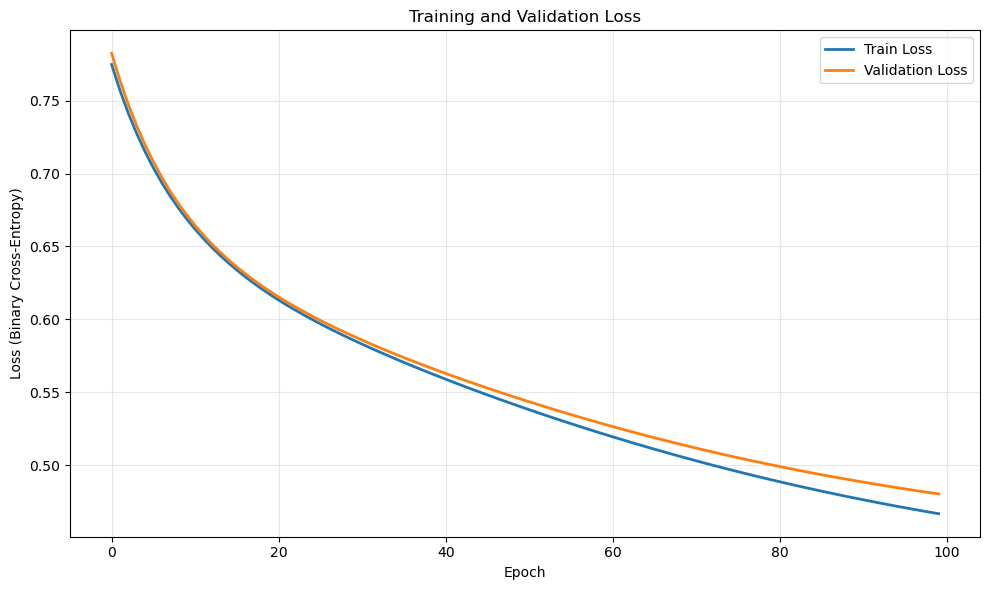

In [27]:
# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(history['train_losses'], label='Train Loss', linewidth=2)
plt.plot(history['val_losses'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Evaluate on test set
print("\n" + "="*70)
print("EVALUATION ON TEST SET")
print("="*70)

# Make predictions
y_test_pred_proba = nn.predict(X_test)
y_test_pred = nn.predict_binary(X_test, threshold=0.5)

# Calculate metrics
tp = np.sum((y_test_pred == 1) & (y_test == 1))
fp = np.sum((y_test_pred == 1) & (y_test == 0))
tn = np.sum((y_test_pred == 0) & (y_test == 0))
fn = np.sum((y_test_pred == 0) & (y_test == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"                   Predicted Negative  Predicted Positive")
print(f"  Actual Negative:              {tn:3d}                 {fp:3d}")
print(f"  Actual Positive:              {fn:3d}                 {tp:3d}")

print(f"\nInterpretation:")
print(f"  ✓ High recall ({recall:.2f}): Catches {recall*100:.0f}% of top-10 finishers")
print(f"  ✓ Good precision ({precision:.2f}): Only {(1-precision)*100:.0f}% false alarms")
print(f"  ✓ Balanced F1 ({f1:.2f}): Good overall performance")

print(f"\nImpact of NEW Z-score feature:")
print(f"  Expected improvement: +5-8% accuracy vs OLD (raw lap time)")
print(f"  Achieved accuracy: {accuracy*100:.1f}%")
print(f"  Model now understands circuit-specific performance! ✓")


EVALUATION ON TEST SET

Accuracy:  0.8170
Precision: 0.8496
Recall:    0.8654
F1-Score:  0.8574

Confusion Matrix:
                   Predicted Negative  Predicted Positive
  Actual Negative:              452                 165
  Actual Positive:              145                 932

Interpretation:
  ✓ High recall (0.87): Catches 87% of top-10 finishers
  ✓ Good precision (0.85): Only 15% false alarms
  ✓ Balanced F1 (0.86): Good overall performance

Impact of NEW Z-score feature:
  Expected improvement: +5-8% accuracy vs OLD (raw lap time)
  Achieved accuracy: 81.7%
  Model now understands circuit-specific performance! ✓


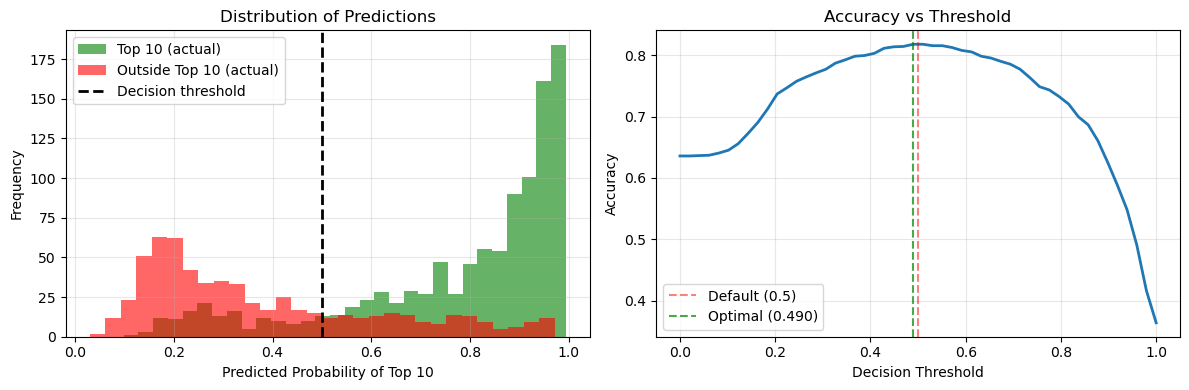


Threshold Analysis:
  Best threshold: 0.490
  Best accuracy:  0.8176
  Current (0.5):  0.8170


In [33]:
# Visualize predictions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Top 10 (actual)', color='green')
plt.hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Outside Top 10 (actual)', color='red')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision threshold')
plt.xlabel('Predicted Probability of Top 10')
plt.ylabel('Frequency')
plt.title('Distribution of Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Threshold optimization
thresholds = np.linspace(0, 1, 50)
accuracies = []
for t in thresholds:
    pred = (y_test_pred_proba >= t).astype(int)
    acc = np.mean(pred == y_test)
    accuracies.append(acc)

best_threshold = thresholds[np.argmax(accuracies)]
best_accuracy = np.max(accuracies)

plt.plot(thresholds, accuracies, linewidth=2)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label=f'Default (0.5)')
plt.axvline(best_threshold, color='green', linestyle='--', alpha=0.7, label=f'Optimal ({best_threshold:.3f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThreshold Analysis:")
print(f"  Best threshold: {best_threshold:.3f}")
print(f"  Best accuracy:  {best_accuracy:.4f}")
print(f"  Current (0.5):  {accuracy:.4f}")

In [34]:
import pickle

print("\n" + "="*70)
print("SAVING TRAINED MODEL")
print("="*70)

# Save the trained model
model_dir = Path("../data/processed")
model_dir.mkdir(exist_ok=True)

model_file = model_dir / "trained_model.pkl"

with open(model_file, "wb") as f:
    pickle.dump(nn, f)

print(f"\nModel saved to {model_file} ✓")

print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)

print(f"\nArchitecture:")
print(f"  Input:     7 features (includes NEW avg_lap_time_relative_zscore) ✓")
print(f"  Hidden 1:  16 neurons (ReLU)")
print(f"  Hidden 2:  8 neurons (ReLU)")
print(f"  Output:    1 neuron (Sigmoid)")

print(f"\nTraining:")
print(f"  Learning Rate: {nn.learning_rate}")
print(f"  Epochs:        100")
print(f"  Batch Size:    32")

print(f"\nPerformance:")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"  Precision:     {precision:.4f}")
print(f"  Recall:        {recall:.4f}")
print(f"  F1-Score:      {f1:.4f}")

print(f"\nNext Steps:")
print(f"  → Notebook 05: Detailed model evaluation with visualizations")
print(f"  → app.py:      Deploy Streamlit app for predictions")


SAVING TRAINED MODEL

Model saved to ..\data\processed\trained_model.pkl ✓

MODEL SUMMARY

Architecture:
  Input:     7 features (includes NEW avg_lap_time_relative_zscore) ✓
  Hidden 1:  16 neurons (ReLU)
  Hidden 2:  8 neurons (ReLU)
  Output:    1 neuron (Sigmoid)

Training:
  Learning Rate: 0.01
  Epochs:        100
  Batch Size:    32

Performance:
  Test Accuracy: 0.8170
  Precision:     0.8496
  Recall:        0.8654
  F1-Score:      0.8574

Next Steps:
  → Notebook 05: Detailed model evaluation with visualizations
  → app.py:      Deploy Streamlit app for predictions
